In [7]:
library(ape)
library(ggnewscale)
library(ggplot2)
library(ggtree)
library(ggtreeExtra)
library(RColorBrewer)
library(tidyverse)

Warning message:
"package 'ggtree' was built under R version 4.5.3"
ggtree v4.0.5 Learn more at https://yulab-smu.top/contribution-tree-data/

Please cite:

Guangchuang Yu, Tommy Tsan-Yuk Lam, Huachen Zhu, Yi Guan. Two methods
for mapping and visualizing associated data on phylogeny using ggtree.
Molecular Biology and Evolution. 2018, 35(12):3041-3043.
doi:10.1093/molbev/msy194


Attaching package: 'ggtree'


The following object is masked from 'package:tidyr':

    expand


The following object is masked from 'package:ape':

    rotate


ggtreeExtra v1.20.1 Learn more at https://yulab-smu.top/contribution-tree-data/

Please cite:

S Xu, Z Dai, P Guo, X Fu, S Liu, L Zhou, W Tang, T Feng, M Chen, L
Zhan, T Wu, E Hu, Y Jiang, X Bo, G Yu. ggtreeExtra: Compact
visualization of richly annotated phylogenetic data. Molecular Biology
and Evolution. 2021, 38(9):4039-4042. doi: 10.1093/molbev/msab166



In [8]:
getwd()

[1] "f:/Data/global/binning/newtreeplot"

In [9]:
tree = read.tree("combined_tree.tree")
mag_tax = read.delim("gtdbtk.tsv")
quality = read.delim("checkm2.tsv")
colnames(mag_tax) = c("MAG", "classification")
mag_tax = separate(mag_tax, classification, into = c("Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"),  sep = ";", fill = "right", remove = F) %>% select(-classification)

In [10]:
mag_list = mag_tax %>% select(MAG, Phylum) %>% 
  split(.$Phylum) %>% 
  lapply(function(x) x$MAG)

In [11]:
tree = groupOTU(tree, mag_list)

In [ ]:
getPaletteBact = colorRampPalette(brewer.pal(45, "Set1"))
Color = getPaletteBact(45)

Warning message in brewer.pal(45, "Set1"):
"n too large, allowed maximum for palette Set1 is 9
Returning the palette you asked for with that many colors
"


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggtree package.
  Please report the issue at <https://github.com/YuLab-SMU/ggtree/issues>."


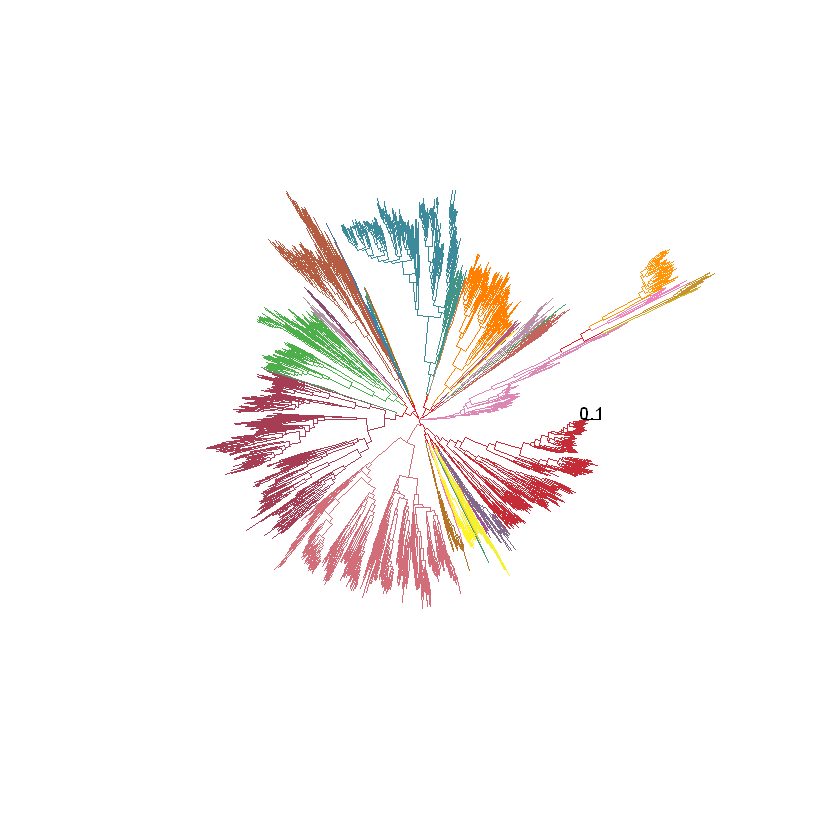

In [13]:
p1 = ggtree(tree,
         layout = 'circular',
         aes(color = group)) + #
  geom_tree() +
  theme_tree() +
  geom_treescale(width	= 0.1) +
  scale_color_manual(values	= Color,
                     na.value = "transparent",
                     guide = "none") +
  #geom_text2(aes(subset=!isTip,	label=node), hjust=-.3)+
  theme(legend.position = "right") 

p1

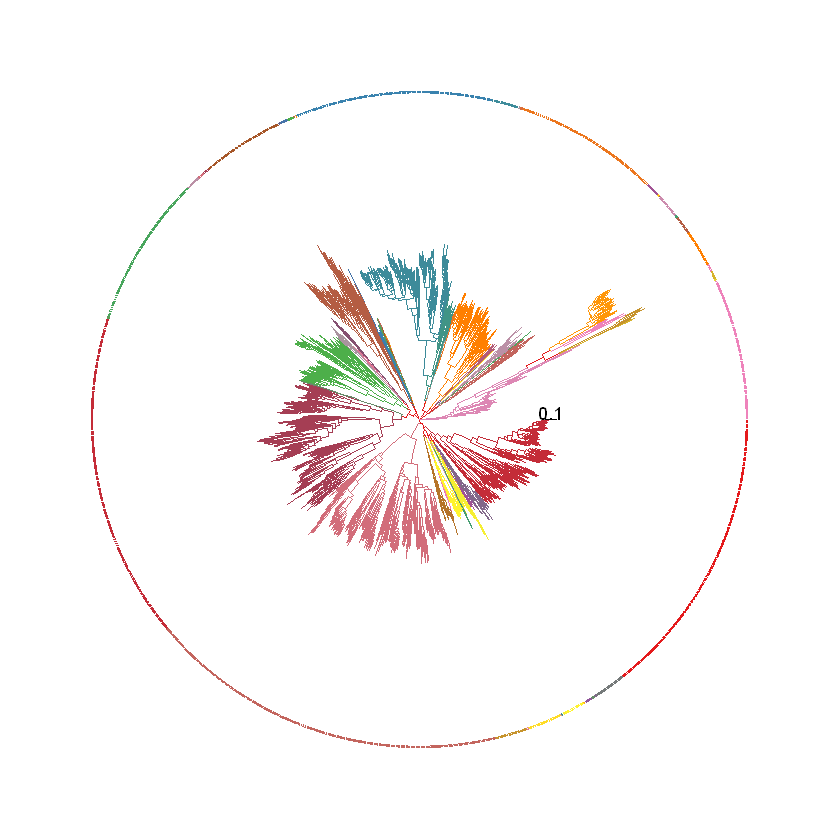

In [14]:
p2 = p1 + new_scale_colour() +
    new_scale_fill() +
    geom_fruit(data = mag_tax, pwidth = 0.01, geom = geom_bar,mapping = aes(y = MAG, fill = Phylum, x = 1),
    offset = 0.3,
    stat = "identity") +
    scale_fill_manual(values = Color) +
    labs(fill = "Taxa") +
    theme(legend.position = "none") +
  new_scale_color() +
  new_scale_fill() 

p2

In [15]:
completeness = quality %>% select(X.MAG_id, Completeness) %>% column_to_rownames(var = "X.MAG_id")
contamination = quality %>% select(X.MAG_id, Contamination) %>% column_to_rownames(var = "X.MAG_id")
genomesize = quality %>% select(X.MAG_id, Genome_Size) %>% column_to_rownames(var = "X.MAG_id")
#genomesize$Genome_Size = log10(genomesize$Genome_Size)

In [16]:
copleteness = rownames_to_column(completeness, var = "MAG")
contamination = rownames_to_column(contamination, var = "MAG")
head(copleteness,1)

,MAG,Completeness
,<chr>,<dbl>
1,MAG_1,98


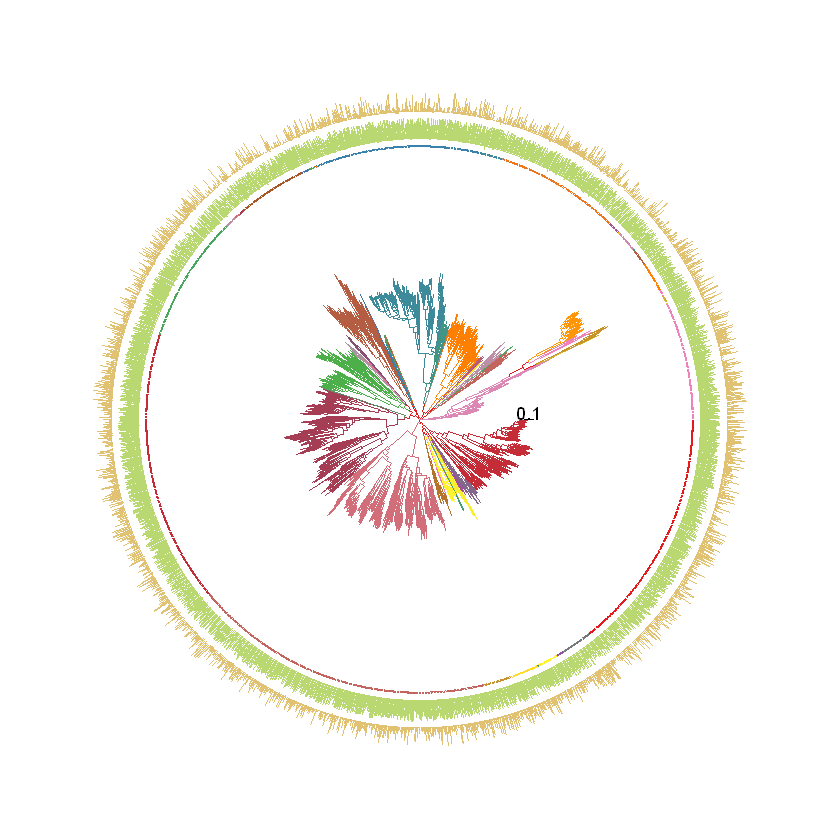

In [17]:
p3 = p2 + geom_fruit(data = copleteness, geom = geom_bar, mapping = aes(y = MAG, x = Completeness), pwidth = 0.1,
    stat = "identity", color = "#bad872", width = 0.05) +
    geom_fruit(data = contamination, geom = geom_bar, mapping = aes(y = MAG, x = Contamination), pwidth = 0.1,
    stat = "identity", color = "#e1c172", width = 0.05)

p3

In [ ]:
MAG_meta = read.csv("MAG_meta2.csv", row.names = 1)
MAG_meta$Genome_Size = MAG_meta$Genome_Size / 1e+06

In [19]:
continents =select(MAG_meta, NorthAmerica, Asia, SouthAmerica, Oceania, European, Africa)
soiltype = select(MAG_meta, AS,NS)

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


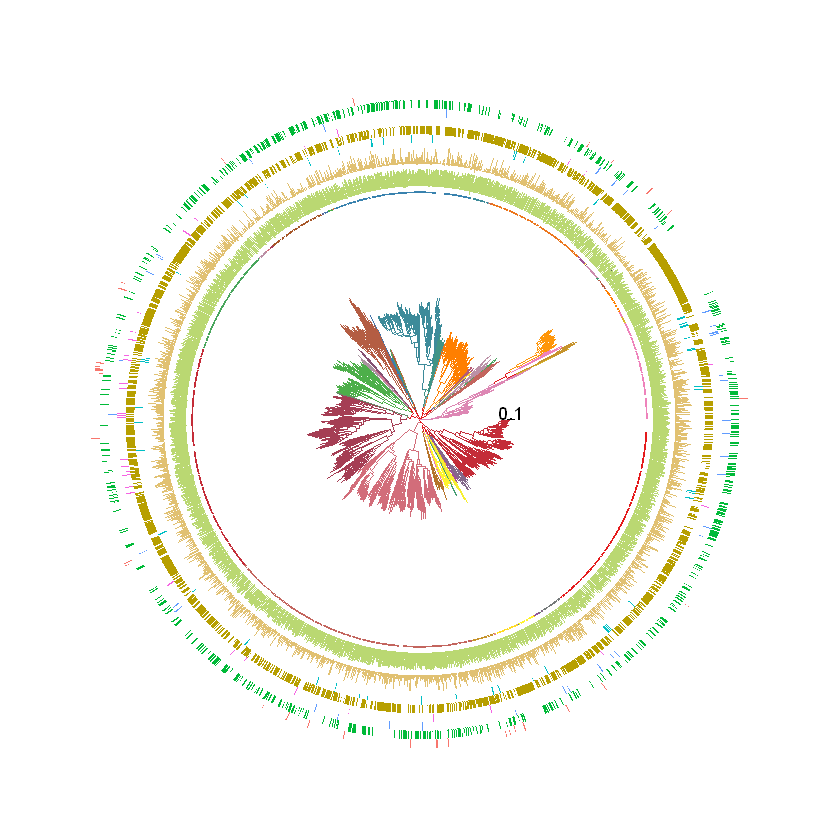

In [20]:
p4 = gheatmap(p3, continents,, width = 0.3, offset = 1.15, colnames = FALSE, color = NULL) +
    scale_fill_discrete(na.translate = F) +
    theme(legend.position = "none") +
    new_scale_fill()+
    new_scale_colour()
p4

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


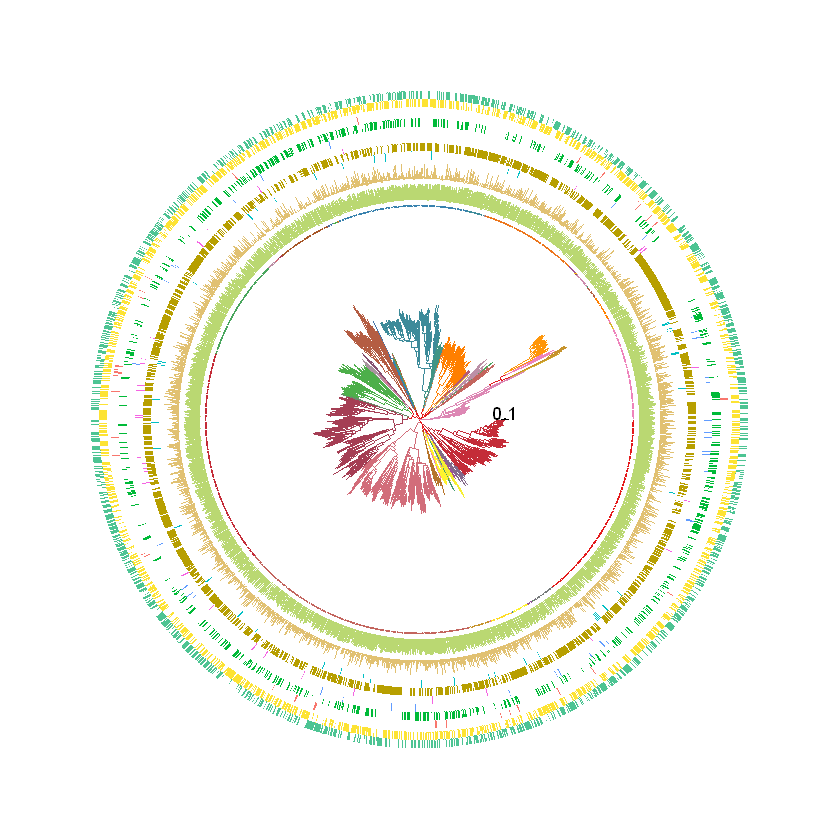

In [21]:
p5 = gheatmap(p4, soiltype, width = 0.1, offset = 1.8, colnames = FALSE, color = NULL) +
    scale_fill_manual(values = c("#fde333","#4dc493"), na.translate = F) +
    theme(legend.position = "none") +
    new_scale_fill()+
    new_scale_colour()

p5

In [22]:
mag_yas_mean_wider = read.csv("mag_yas_mean_wider.csv", row.names = 1)

In [24]:
head(mag_yas_mean_wider)

,Growth.potential,Resource.acquisition,Stress.tolerance
,<dbl>,<dbl>,<dbl>
MAG_1,0.50034989,0.089082708,0.40816356
MAG_10,0.41811715,0.189778681,0.30796955
MAG_100,0.12898527,0.170786042,0.06641458
MAG_1000,0.46601396,0.050510360,0.12289875
MAG_1001,0.09159223,0.009219485,0.09550239
MAG_1002,0.18429494,0.406954220,0.11147520


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


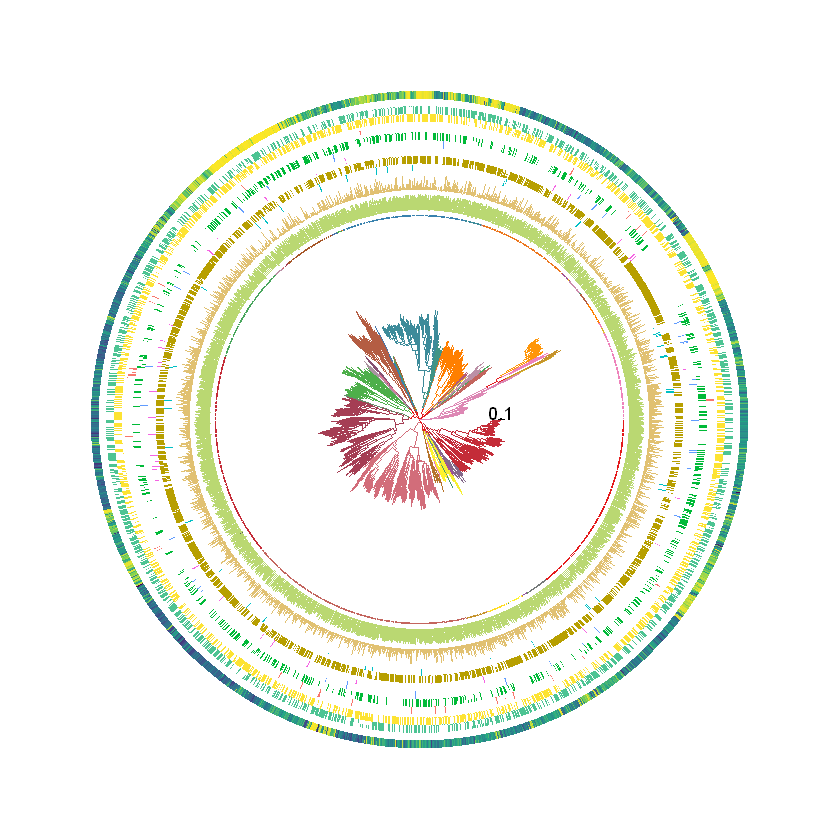

In [25]:
p6 = gheatmap(p5, data = select(mag_yas_mean_wider, `Growth.potential`), offset = 2.1, width = 0.05, colnames = F, color = NULL) +
    scale_fill_viridis_c(direction = -1) +
    theme(legend.position = "none") +
    new_scale_colour() +
    new_scale_fill() 

p6

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


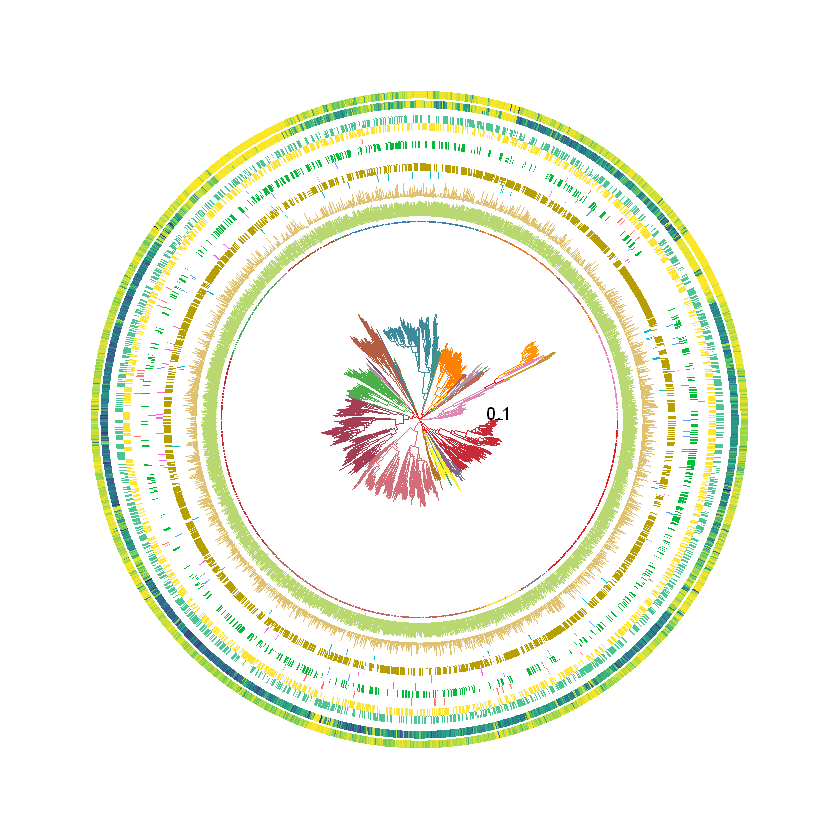

In [26]:
p7 = gheatmap(p6, data = select(mag_yas_mean_wider, `Resource.acquisition`), offset = 2.23, width = 0.05, colnames = F, color = NULL) +
    scale_fill_viridis_c(direction = -1) +
    theme(legend.position = "none") +
    new_scale_colour() +
    new_scale_fill() 

p7

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


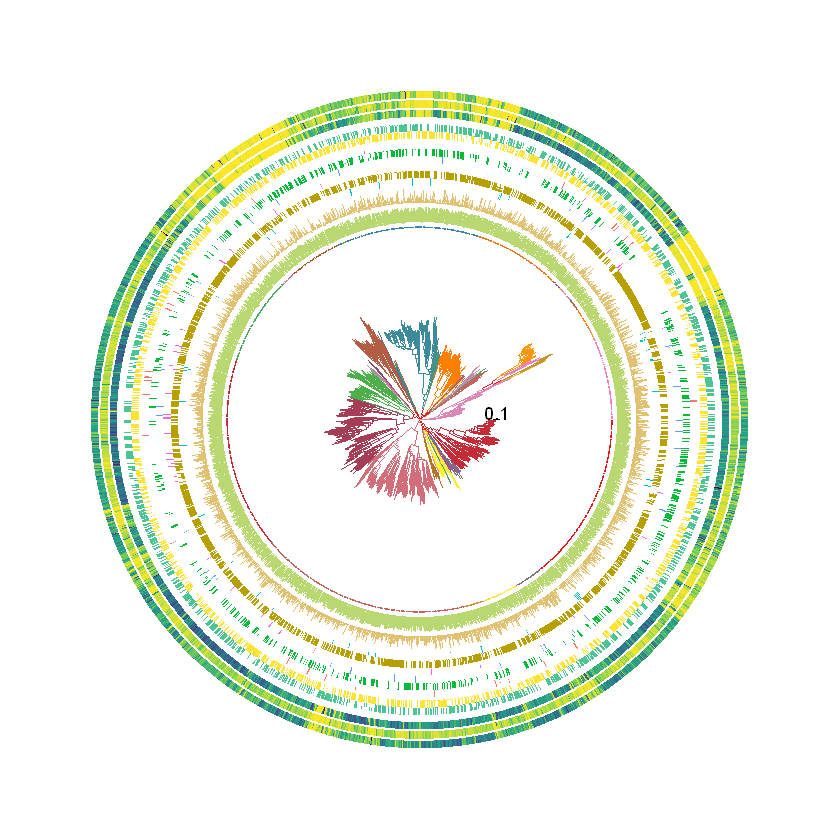

In [27]:
p8 = gheatmap(p7, data = select(mag_yas_mean_wider, `Stress.tolerance`), offset = 2.36, width = 0.05, colnames = F, color = NULL) +
    scale_fill_viridis_c(direction = -1) +
    theme(legend.position = "none") +
    new_scale_colour() +
    new_scale_fill() 

p8

Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


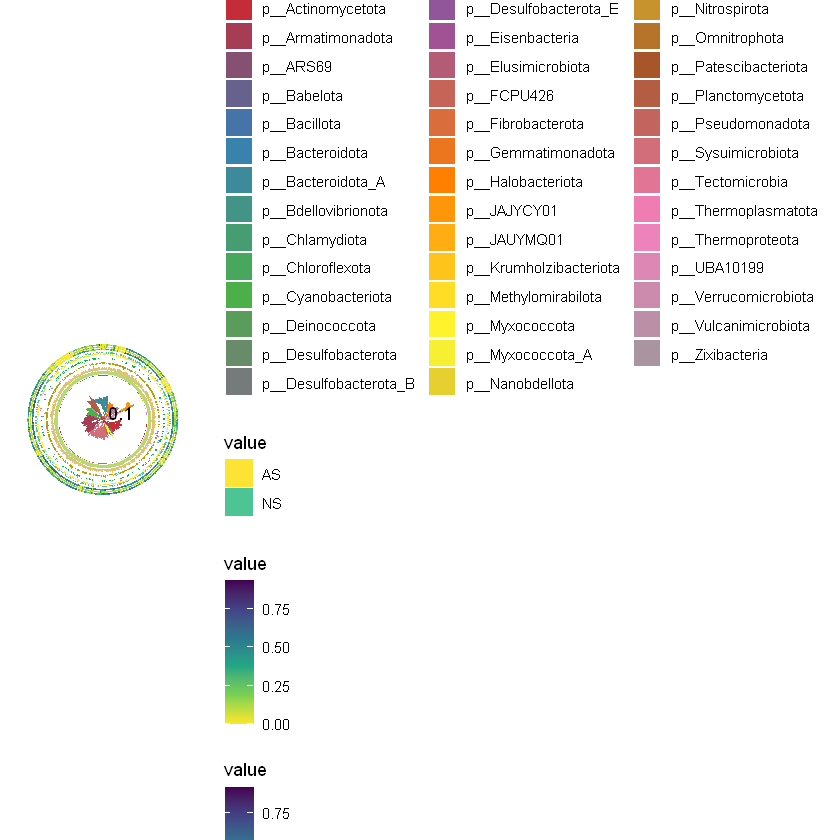

In [29]:
p8_legend = gheatmap(p7, data = select(mag_yas_mean_wider, `Stress.tolerance`), offset = 2.36, width = 0.05, colnames = F, color = NULL) +
    scale_fill_viridis_c(direction = -1) +
    #theme(legend.position = "none") +
    new_scale_colour() +
    new_scale_fill() 

p8_legend

In [30]:
ggsave("binning_tree_added_yas_ab.pdf", p8, height = 15, width = 15)
ggsave("binning_tree_added_yas_ab_legend.pdf", p8_legend, height = 15, width = 15)